# 4.6 Conditional Sensitivity to Initial Yield Curve

Evaluates how sensitive each generative model is to the **initial yield curve** used as starting condition.

Three representative regimes:
- **Curve 1 — High-rate (2002):** ~5.4% long-end
- **Curve 2 — Medium-rate (2015):** near-zero short end, ~2.8% 30Y
- **Curve 3 — Low-rate (2018):** flat ~3% across the curve

Each model generates 200 scenarios × 60 monthly steps per initial curve.

**Sections:** Setup → Fan plots → Mean trajectories → NS factor evolution → Month-60 distributions → Summary table → Cross-regime sensitivity score


## 1. Setup & Data Loading

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ── Maturity labels (short names used throughout) ────────────────────────────
MATURITIES = ["1M","3M","6M","1Y","2Y","3Y","5Y","7Y","10Y","20Y","30Y"]

# ── Regime definitions (Start_Curve_ID → label & colour) ────────────────────
REGIMES = {
    1: "High-rate (2002)",
    2: "Medium-rate (2015)",
    3: "Low-rate (2018)",
}
REGIME_COLORS = {1: "#C62828", 2: "#1565C0", 3: "#2E7D32"}

# ── Load initial curves (flexible: handles Yield_XY or bare XY column names,
#    with or without a Regime/index column) ───────────────────────────────────
INITIAL_CURVES_PATH = "initial_curves.csv"

_ic_raw = pd.read_csv(INITIAL_CURVES_PATH)

# Normalise column names → bare maturity labels
_rename = {}
for col in _ic_raw.columns:
    stripped = col.strip()
    # "Yield_1M" → "1M",  "1M" → "1M",  "Regime" → "Regime"
    bare = stripped.replace("Yield_", "") if stripped.startswith("Yield_") else stripped
    _rename[col] = bare
_ic_raw = _ic_raw.rename(columns=_rename)

# Drop any non-maturity columns (e.g. "Regime", "index")
_ic_raw = _ic_raw[[m for m in MATURITIES if m in _ic_raw.columns]]

# Map regime_id (1-indexed row) → 11-element yield array
INITIAL_YIELDS = {
    i+1: _ic_raw.iloc[i].values.astype(float)
    for i in range(len(_ic_raw))
}

print("Initial curves loaded:")
print(_ic_raw.round(4).to_string())
print()
for rid, label in REGIMES.items():
    if rid in INITIAL_YIELDS:
        print(f"  Curve {rid} ({label}): 30Y = {INITIAL_YIELDS[rid][-1]:.2f}%")


Initial curves loaded:
       1M      3M      6M      1Y      2Y      3Y      5Y      7Y     10Y     20Y     30Y
0  1.6125  1.6167  1.6908  1.9500  2.5633  3.0267  3.7367  4.2325  4.5567  5.3950  5.4250
1  0.0342  0.0600  0.1783  0.3325  0.6908  1.0100  1.4983  1.8600  2.1042  2.5258  2.8158
2  1.8917  2.0050  2.1750  2.3642  2.5267  2.6217  2.7325  2.8300  2.8900  3.0000  3.0950

  Curve 1 (High-rate (2002)): 30Y = 5.42%
  Curve 2 (Medium-rate (2015)): 30Y = 2.82%
  Curve 3 (Low-rate (2018)): 30Y = 3.10%


In [12]:
# ── Flexible scenario loader ─────────────────────────────────────────────────
# Handles two column formats:
#   Format A (Diffusion):  Scenario_ID, Month, 1M…30Y, Start_Curve_ID
#   Format B (HJM-PCA):    Scenario_ID, Month, Y_1M…Y_30Y  (no Start_Curve_ID)
#
# If Start_Curve_ID is absent, all scenarios are registered under regime 1.

def _detect_mat_cols(df):
    """Return the 11 maturity column names present in df."""
    bare     = [m for m in MATURITIES if m in df.columns]
    prefixed = [f"Y_{m}" for m in MATURITIES if f"Y_{m}" in df.columns]
    if len(bare)     == 11: return bare
    if len(prefixed) == 11: return prefixed
    raise ValueError(f"Cannot find all 11 maturity columns in: {list(df.columns)}")

def load_conditional_data(path, n_scen=200):
    """
    Returns dict:  regime_id (int) → list of (60, 11) arrays
    """
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    mat_cols   = _detect_mat_cols(df)

    result = {}
    if "Start_Curve_ID" in df.columns:
        for rid in sorted(df["Start_Curve_ID"].unique()):
            sub      = df[df["Start_Curve_ID"] == rid]
            scen_ids = sub["Scenario_ID"].unique()[:n_scen]
            windows  = [sub[sub["Scenario_ID"]==sid][mat_cols].values.astype(float)
                        for sid in scen_ids]
            windows  = [w for w in windows if w.shape[0] == 60]
            result[int(rid)] = windows
    else:
        scen_ids = df["Scenario_ID"].unique()[:n_scen]
        windows  = [df[df["Scenario_ID"]==sid][mat_cols].values.astype(float)
                    for sid in scen_ids]
        windows  = [w for w in windows if w.shape[0] == 60]
        result[1] = windows   # assign to regime 1 by default

    return result

# ── Model registry — add / uncomment as new files arrive ────────────────────
MODELS = {
    "Diffusion": "diffusion_3 scenarios 6-5.csv",
    "HJM-PCA":   "hjm_pca_3 scenarios 6-5.csv",
    # "CANN":    "cann_3 scenarios X-X.csv",
    # "VAE":     "vae_3 scenarios X-X.csv",
}
MODEL_COLORS = {
    "Diffusion": "#1565C0",
    "HJM-PCA":   "#2E7D32",
    "CANN":      "#6A1B9A",
    "VAE":       "#C62828",
}
N_SCEN = 200

# ── Load ─────────────────────────────────────────────────────────────────────
model_data = {}
for name, path in MODELS.items():
    model_data[name] = load_conditional_data(path, n_scen=N_SCEN)
    for rid, windows in model_data[name].items():
        label = REGIMES.get(rid, f"Curve {rid}")
        print(f"  {name:12s} | {label:22s}: {len(windows)} scenarios loaded")

all_regimes = sorted({rid for md in model_data.values() for rid in md})
MONTHS      = np.arange(1, 61)


  Diffusion    | High-rate (2002)      : 200 scenarios loaded
  Diffusion    | Medium-rate (2015)    : 200 scenarios loaded
  Diffusion    | Low-rate (2018)       : 200 scenarios loaded
  HJM-PCA      | High-rate (2002)      : 200 scenarios loaded
  HJM-PCA      | Medium-rate (2015)    : 200 scenarios loaded
  HJM-PCA      | Low-rate (2018)       : 200 scenarios loaded


## 2. Fan Plots — Yield Path Distributions per Regime

For each model: **P5–P95 band** (shaded) + **mean trajectory** (solid line),
shown for maturities **3M**, **2Y**, **10Y**. Dotted horizontal line = initial yield.


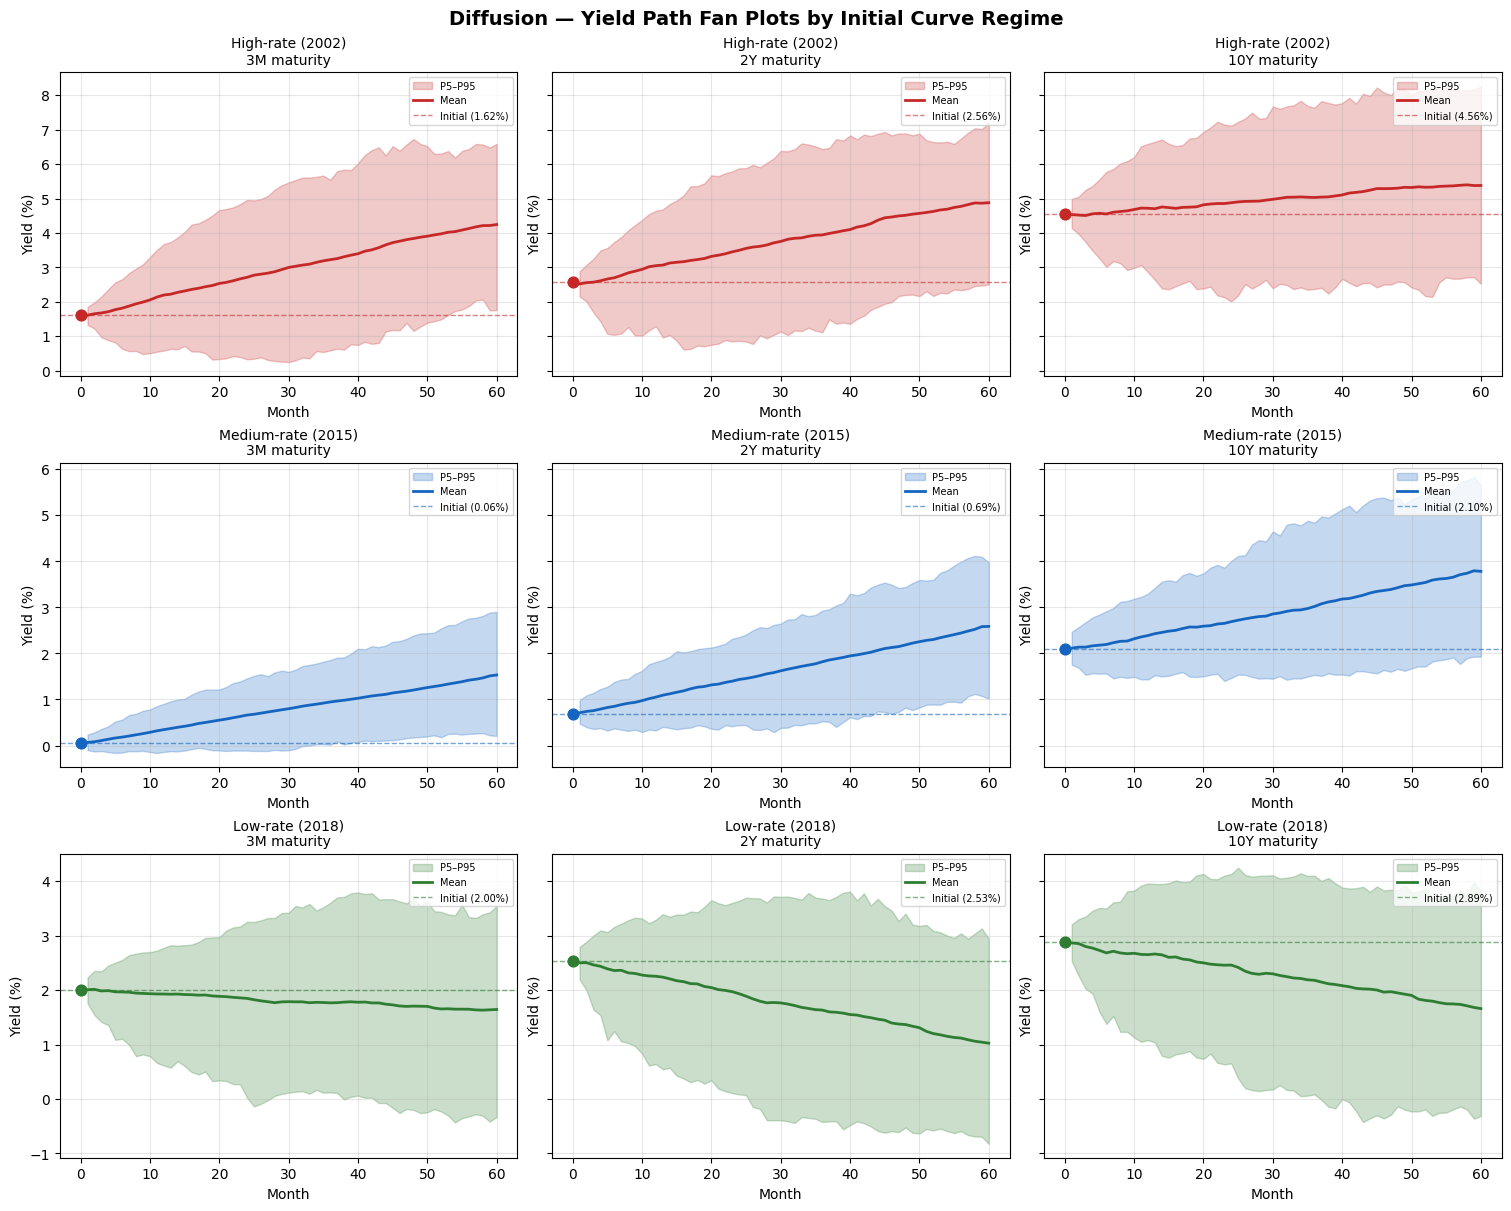

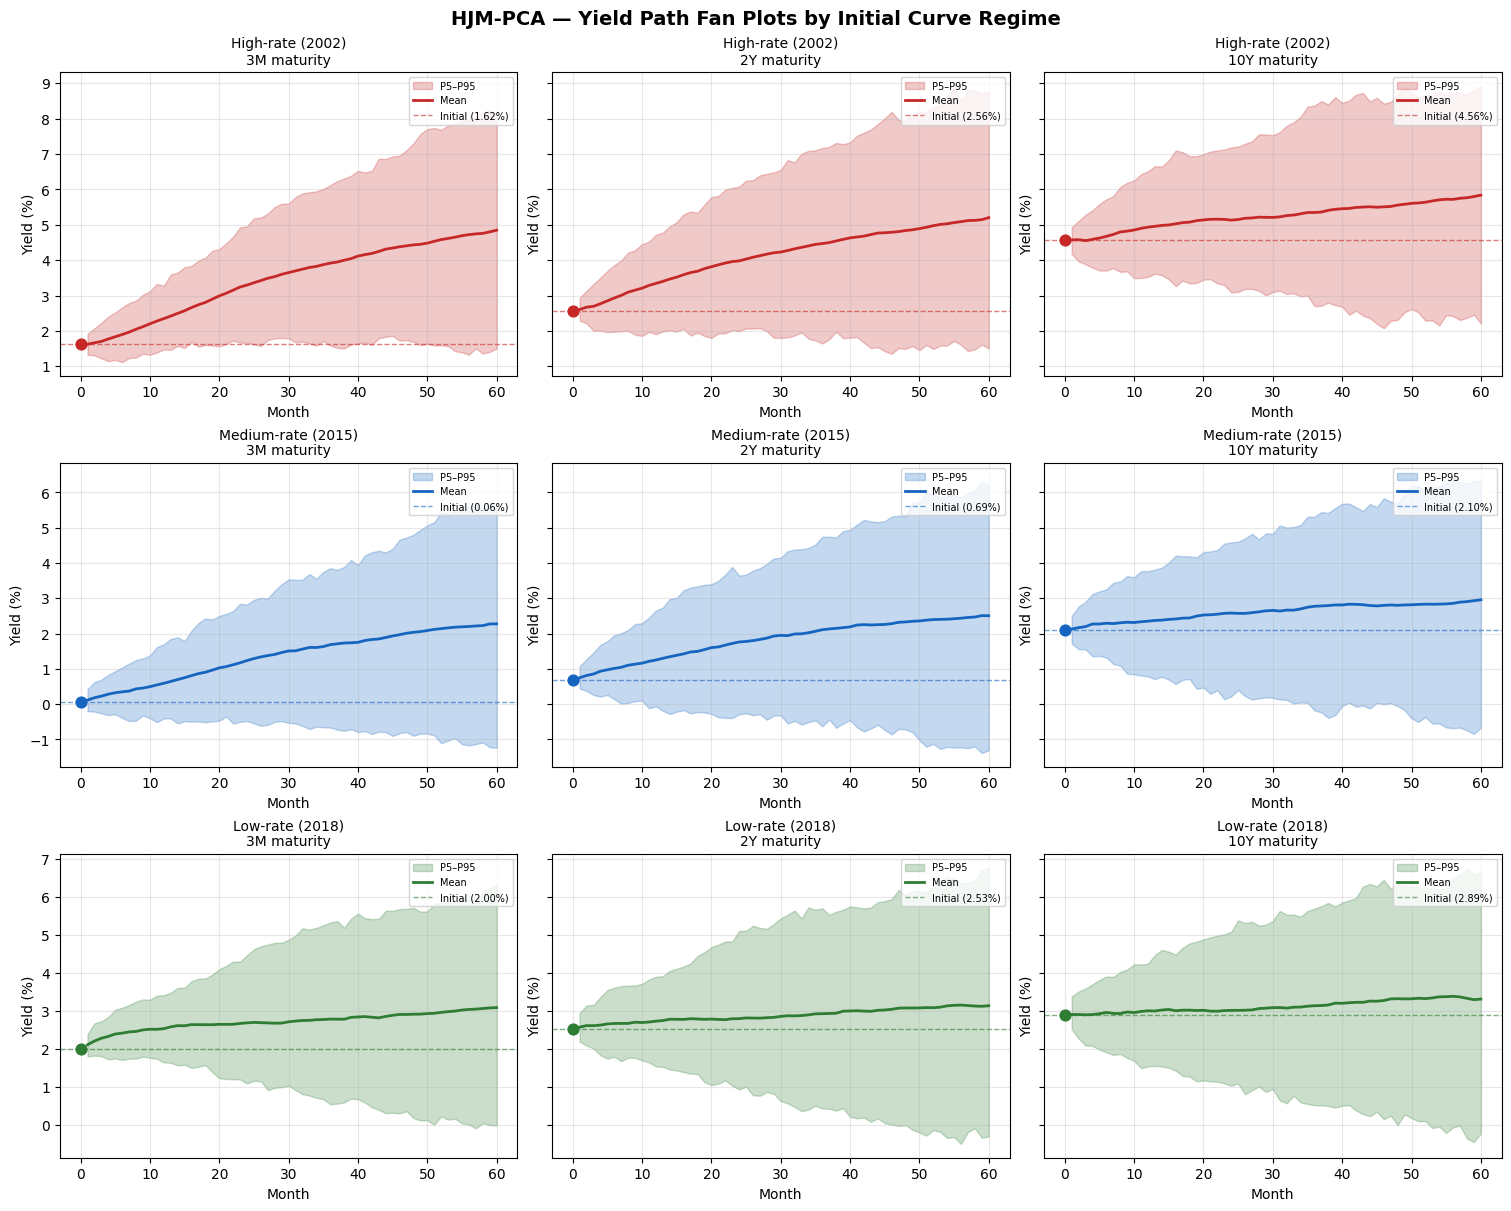

In [13]:
FOCUS_MATS = ["3M", "2Y", "10Y"]
FOCUS_IDX  = [MATURITIES.index(m) for m in FOCUS_MATS]

for model_name, regime_dict in model_data.items():
    n_regimes = len(regime_dict)
    fig, axes = plt.subplots(
        n_regimes, len(FOCUS_MATS),
        figsize=(5*len(FOCUS_MATS), 4*n_regimes),
        constrained_layout=True, sharey="row",
    )
    if n_regimes == 1:
        axes = [axes]

    fig.suptitle(f"{model_name} — Yield Path Fan Plots by Initial Curve Regime",
                 fontsize=14, fontweight="bold")

    for row_i, (rid, windows) in enumerate(sorted(regime_dict.items())):
        label = REGIMES.get(rid, f"Curve {rid}")
        color = REGIME_COLORS.get(rid, "#555555")
        arr   = np.array(windows)          # (N, 60, 11)

        for col_i, (mat_name, mat_idx) in enumerate(zip(FOCUS_MATS, FOCUS_IDX)):
            ax     = axes[row_i][col_i]
            series = arr[:, :, mat_idx]    # (N, 60)
            p5     = np.percentile(series,  5, axis=0)
            p95    = np.percentile(series, 95, axis=0)
            mean   = series.mean(axis=0)

            ax.fill_between(MONTHS, p5, p95, alpha=0.25, color=color, label="P5–P95")
            ax.plot(MONTHS, mean, color=color, lw=2, label="Mean")

            if rid in INITIAL_YIELDS:
                y0 = INITIAL_YIELDS[rid][MATURITIES.index(mat_name)]
                ax.axhline(y0, color=color, lw=1, ls="--", alpha=0.6,
                           label=f"Initial ({y0:.2f}%)")
                ax.scatter([0], [y0], color=color, s=60, zorder=5)

            ax.set_title(f"{label}\n{mat_name} maturity", fontsize=10)
            ax.set_xlabel("Month"); ax.set_ylabel("Yield (%)")
            ax.legend(fontsize=7, loc="upper right")
            ax.grid(True, alpha=0.3)

    plt.show()


## 3. Mean Trajectory Comparison Across Models

Overlays the **mean path** of every model on the same axes for each regime.
Shows whether models agree on the expected rate direction from the same starting point.


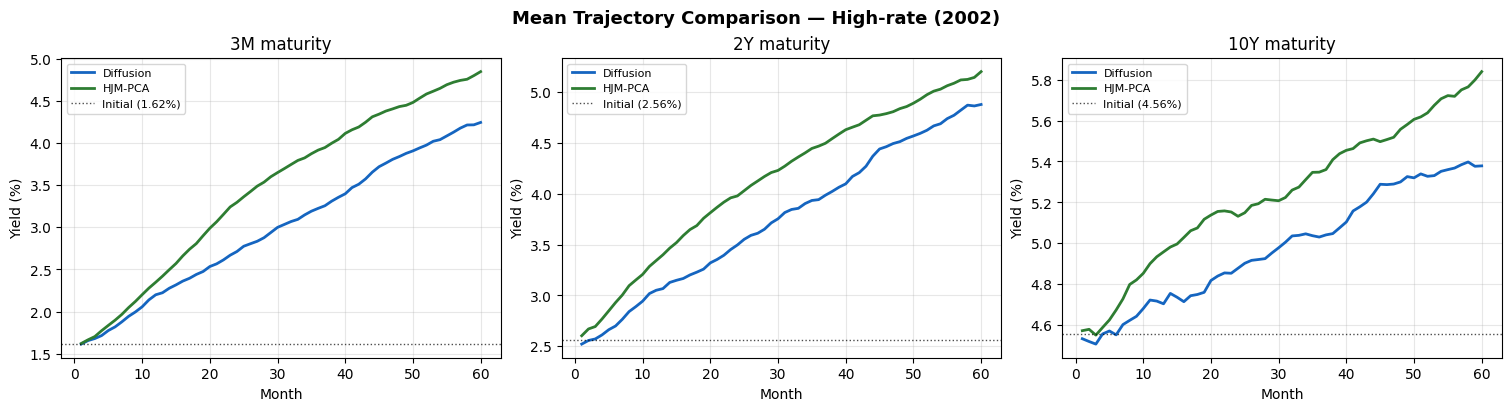

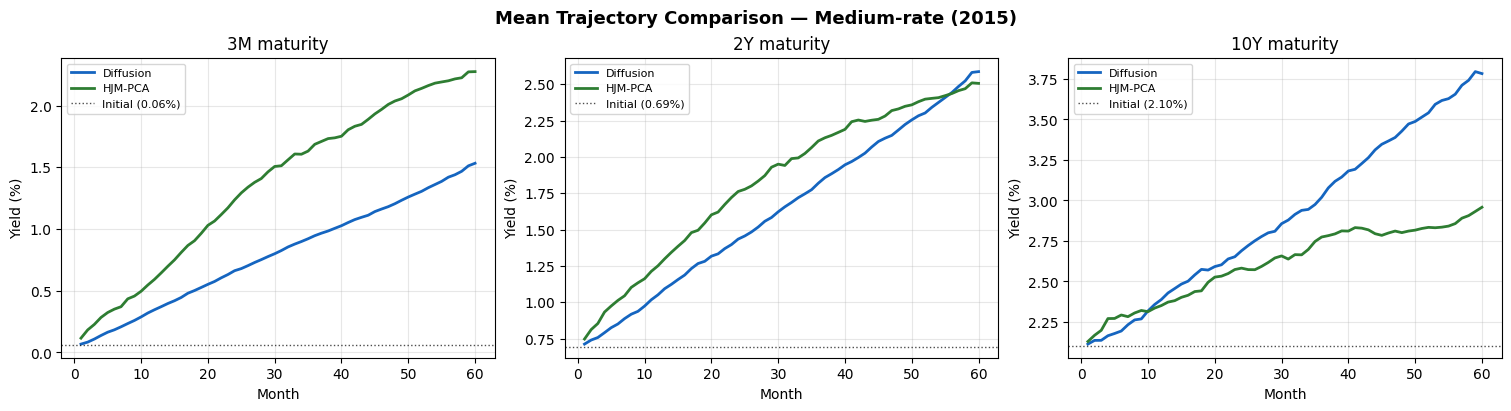

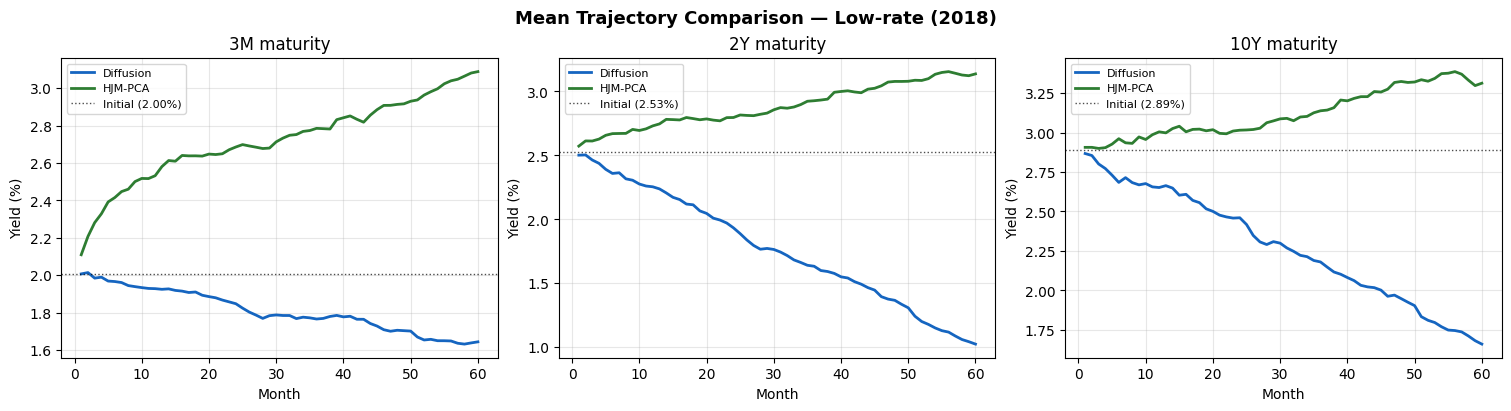

In [14]:
for rid in all_regimes:
    label = REGIMES.get(rid, f"Curve {rid}")
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
    fig.suptitle(f"Mean Trajectory Comparison — {label}",
                 fontsize=13, fontweight="bold")

    for col_i, (mat_name, mat_idx) in enumerate(zip(FOCUS_MATS, FOCUS_IDX)):
        ax = axes[col_i]
        for model_name, regime_dict in model_data.items():
            if rid not in regime_dict:
                continue
            arr   = np.array(regime_dict[rid])
            mean  = arr[:, :, mat_idx].mean(axis=0)
            color = MODEL_COLORS.get(model_name, "black")
            ax.plot(MONTHS, mean, color=color, lw=2, label=model_name)

        if rid in INITIAL_YIELDS:
            y0 = INITIAL_YIELDS[rid][MATURITIES.index(mat_name)]
            ax.axhline(y0, color="black", lw=1, ls=":", alpha=0.7,
                       label=f"Initial ({y0:.2f}%)")

        ax.set_title(f"{mat_name} maturity"); ax.set_xlabel("Month")
        ax.set_ylabel("Yield (%)"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.show()


## 4. Nelson–Siegel Factor Evolution

Fit NS (fixed λ = 0.0609) at every month for every scenario.  
Track how **β₁ Level**, **β₂ Slope**, **β₃ Curvature** evolve over 60 months.


In [15]:
from numpy.linalg import lstsq

LAMBDA    = 0.0609
MAT_YEARS = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30])

def ns_basis(t, lam=LAMBDA):
    lt = lam * t
    return np.column_stack([np.ones_like(t),
                            (1-np.exp(-lt))/lt,
                            (1-np.exp(-lt))/lt - np.exp(-lt)])

NS_BASIS = ns_basis(MAT_YEARS)   # (11, 3)

def fit_ns_batch(arr):
    """arr: (N, T, 11)  →  betas: (N, T, 3)"""
    N, T, _ = arr.shape
    betas    = np.zeros((N, T, 3))
    for i in range(N):
        for t in range(T):
            b, *_ = lstsq(NS_BASIS, arr[i, t], rcond=None)
            betas[i, t] = b
    return betas

print("Fitting Nelson-Siegel factors (may take ~30s)…")
model_betas = {}
for model_name, regime_dict in model_data.items():
    model_betas[model_name] = {}
    for rid, windows in regime_dict.items():
        arr   = np.array(windows)
        betas = fit_ns_batch(arr)
        model_betas[model_name][rid] = betas
        print(f"  {model_name} | {REGIMES.get(rid,'Curve '+str(rid))}: done ({arr.shape[0]} scenarios)")

print("All NS fits complete.")


Fitting Nelson-Siegel factors (may take ~30s)…
  Diffusion | High-rate (2002): done (200 scenarios)
  Diffusion | Medium-rate (2015): done (200 scenarios)
  Diffusion | Low-rate (2018): done (200 scenarios)
  HJM-PCA | High-rate (2002): done (200 scenarios)
  HJM-PCA | Medium-rate (2015): done (200 scenarios)
  HJM-PCA | Low-rate (2018): done (200 scenarios)
All NS fits complete.


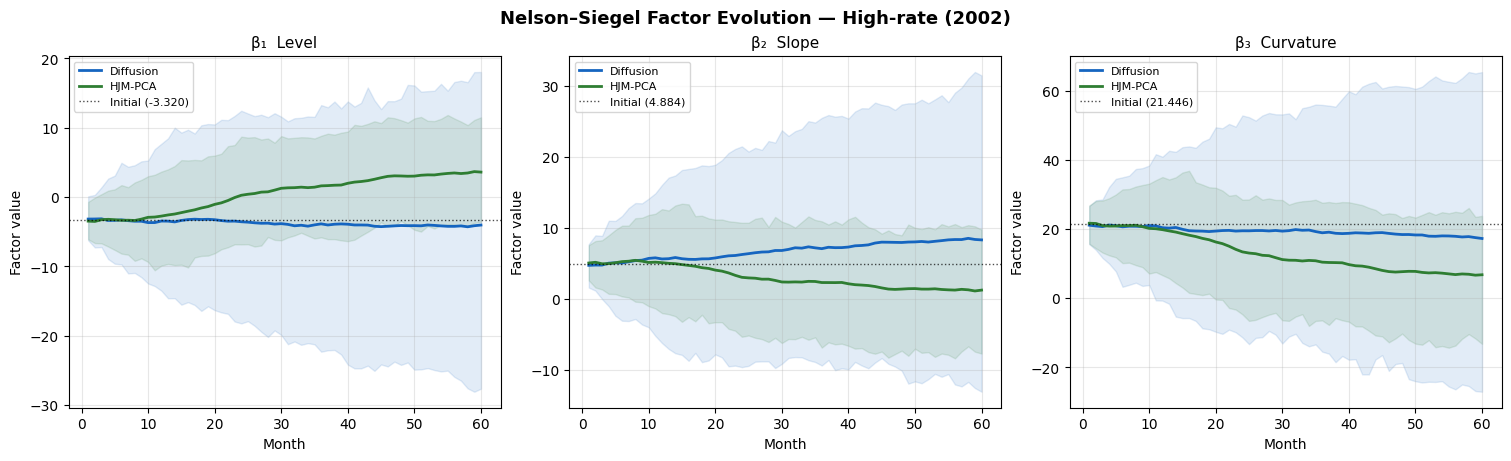

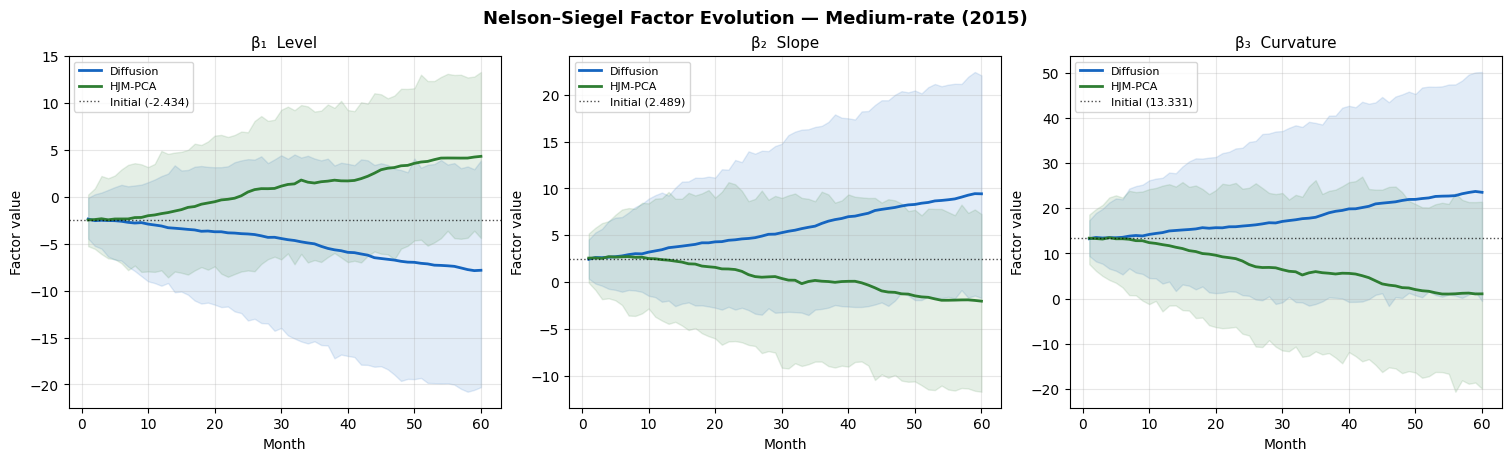

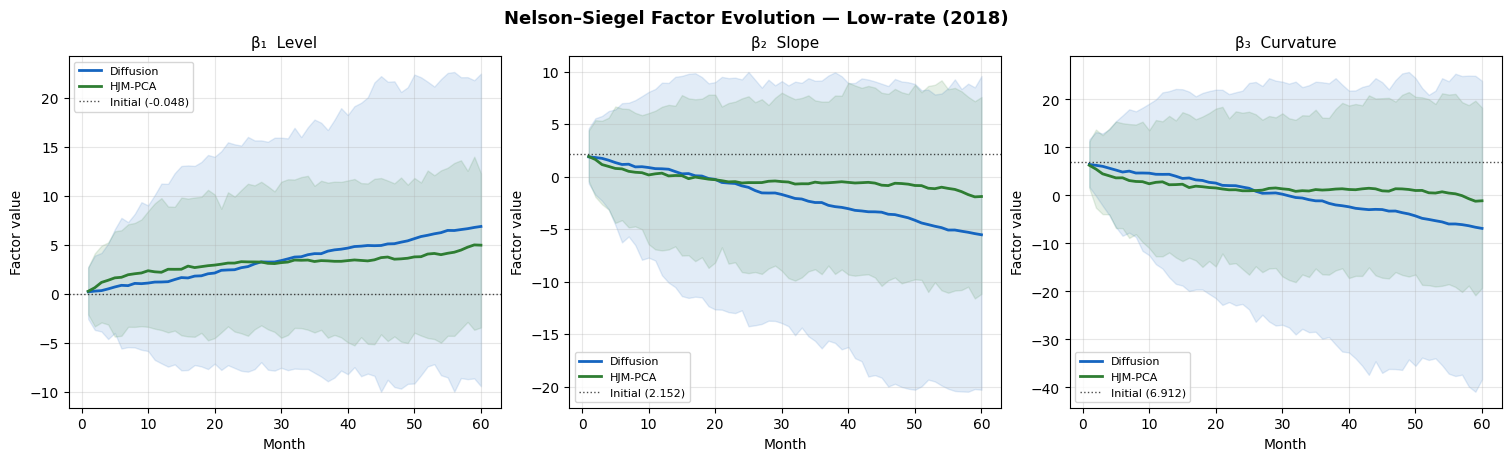

In [16]:
FACTOR_NAMES = ["β₁  Level", "β₂  Slope", "β₃  Curvature"]

for rid in all_regimes:
    label = REGIMES.get(rid, f"Curve {rid}")
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
    fig.suptitle(f"Nelson–Siegel Factor Evolution — {label}",
                 fontsize=13, fontweight="bold")

    for fi, factor_name in enumerate(FACTOR_NAMES):
        ax = axes[fi]
        for model_name, regime_betas in model_betas.items():
            if rid not in regime_betas:
                continue
            betas  = regime_betas[rid]          # (N, 60, 3)
            mean_b = betas[:, :, fi].mean(axis=0)
            p5_b   = np.percentile(betas[:, :, fi],  5, axis=0)
            p95_b  = np.percentile(betas[:, :, fi], 95, axis=0)
            color  = MODEL_COLORS.get(model_name, "black")
            ax.plot(MONTHS, mean_b, color=color, lw=2, label=model_name)
            ax.fill_between(MONTHS, p5_b, p95_b, alpha=0.12, color=color)

        # Initial factor value
        if rid in INITIAL_YIELDS:
            b0, *_ = lstsq(NS_BASIS, INITIAL_YIELDS[rid], rcond=None)
            ax.axhline(b0[fi], color="black", lw=1, ls=":", alpha=0.7,
                       label=f"Initial ({b0[fi]:.3f})")

        ax.set_title(factor_name, fontsize=11)
        ax.set_xlabel("Month"); ax.set_ylabel("Factor value")
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.show()


## 5. Month-60 Terminal Distribution

Histograms of simulated yields at **month 60** for key maturities per regime.
Shows how dispersed the terminal distributions are and whether regime differences persist.


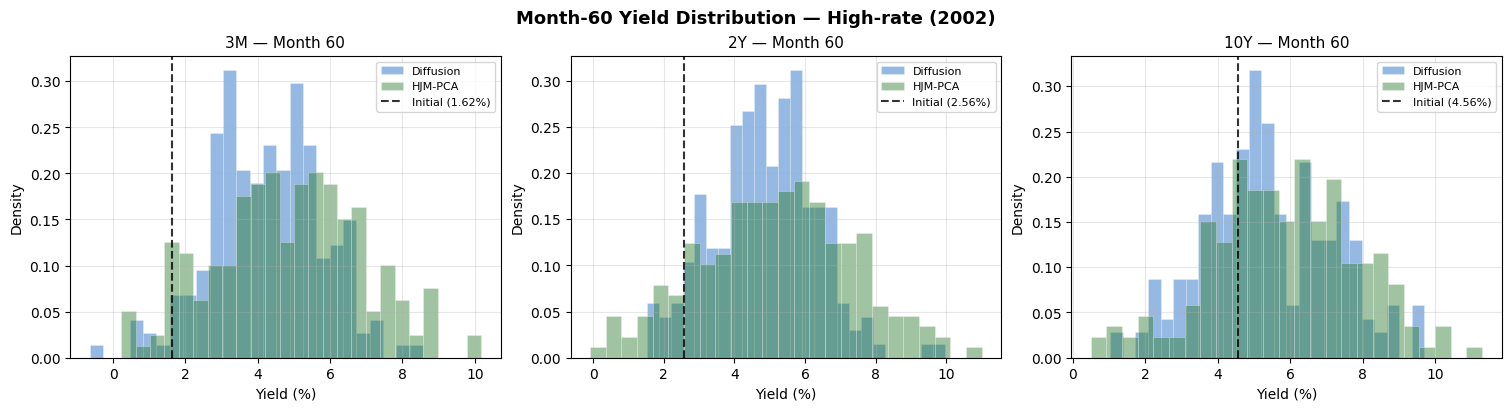

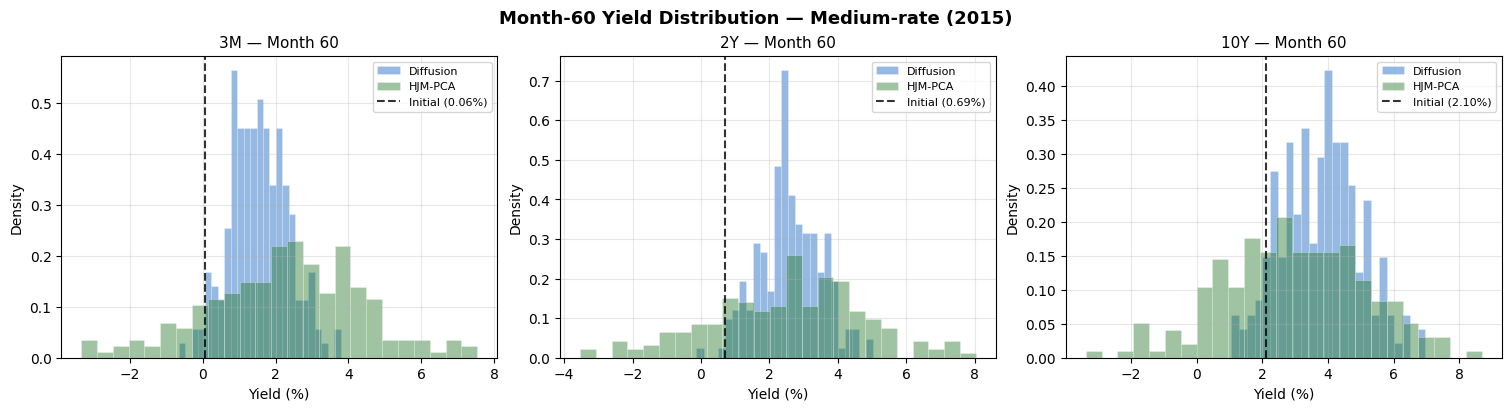

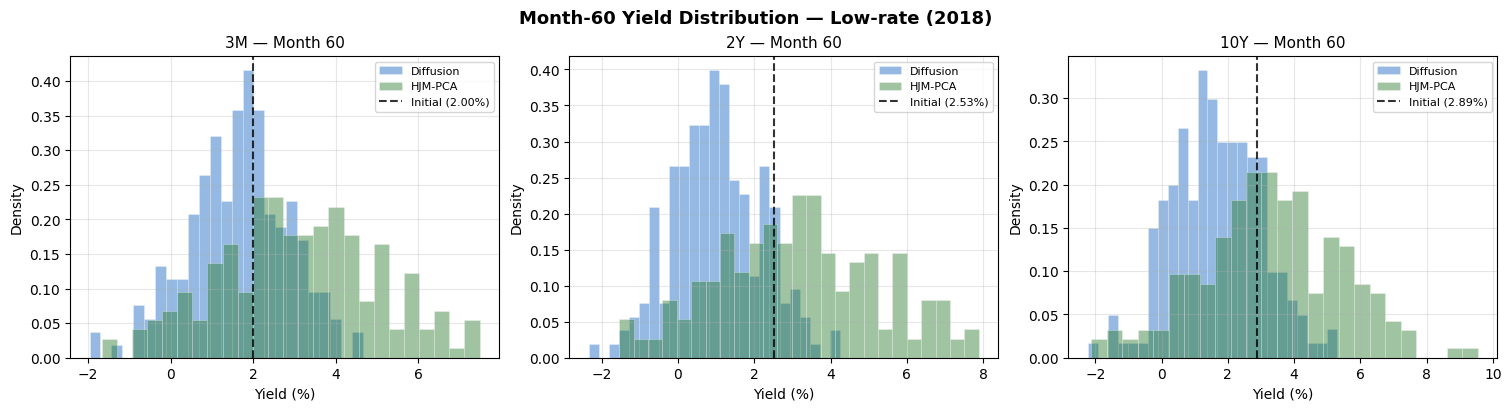

In [17]:
FIN_MATS    = ["3M", "2Y", "10Y"]
FIN_MAT_IDX = [MATURITIES.index(m) for m in FIN_MATS]

for rid in all_regimes:
    label = REGIMES.get(rid, f"Curve {rid}")
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
    fig.suptitle(f"Month-60 Yield Distribution — {label}",
                 fontsize=13, fontweight="bold")

    for col_i, (mat_name, mat_idx) in enumerate(zip(FIN_MATS, FIN_MAT_IDX)):
        ax = axes[col_i]
        for model_name, regime_dict in model_data.items():
            if rid not in regime_dict:
                continue
            arr   = np.array(regime_dict[rid])
            final = arr[:, -1, mat_idx]
            color = MODEL_COLORS.get(model_name, "black")
            ax.hist(final, bins=25, alpha=0.45, color=color, label=model_name,
                    density=True, edgecolor="white", lw=0.4)

        if rid in INITIAL_YIELDS:
            y0 = INITIAL_YIELDS[rid][MATURITIES.index(mat_name)]
            ax.axvline(y0, color="black", lw=1.5, ls="--", alpha=0.8,
                       label=f"Initial ({y0:.2f}%)")

        ax.set_title(f"{mat_name} — Month 60", fontsize=11)
        ax.set_xlabel("Yield (%)"); ax.set_ylabel("Density")
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.show()


## 6. Summary Statistics (Month 60)

For each **model × regime × maturity**: mean, std, drift from initial yield, IQR.


In [18]:
TABLE_MATS = ["3M", "2Y", "10Y"]
TABLE_IDX  = [MATURITIES.index(m) for m in TABLE_MATS]

rows = []
for model_name, regime_dict in model_data.items():
    for rid, windows in sorted(regime_dict.items()):
        label = REGIMES.get(rid, f"Curve {rid}")
        arr   = np.array(windows)
        for mat_name, mat_idx in zip(TABLE_MATS, TABLE_IDX):
            final = arr[:, -1, mat_idx]
            y0    = INITIAL_YIELDS[rid][MATURITIES.index(mat_name)] if rid in INITIAL_YIELDS else np.nan
            rows.append({
                "Model":            model_name,
                "Regime":           label,
                "Maturity":         mat_name,
                "N scen":           len(windows),
                "Initial yield":    round(y0, 4),
                "Mean (t=60)":      round(final.mean(), 4),
                "Std  (t=60)":      round(final.std(), 4),
                "Drift":            round(final.mean() - y0, 4),
                "IQR  (t=60)":      round(np.percentile(final,75) - np.percentile(final,25), 4),
            })

summary_df = pd.DataFrame(rows)

for rid in all_regimes:
    rlabel = REGIMES.get(rid, f"Curve {rid}")
    sub    = summary_df[summary_df["Regime"] == rlabel]
    if sub.empty: continue
    print(f"\n{'='*90}")
    print(f"  {rlabel}")
    print('='*90)
    print(sub.drop(columns="Regime").to_string(index=False))

summary_df.to_csv("conditional_sensitivity_summary.csv", index=False)
print("\n  → saved: conditional_sensitivity_summary.csv")



  High-rate (2002)
    Model Maturity  N scen  Initial yield  Mean (t=60)  Std  (t=60)  Drift  IQR  (t=60)
Diffusion       3M     200         1.6167       4.2445       1.5188 2.6278       2.0916
Diffusion       2Y     200         2.5633       4.8789       1.4705 2.3156       1.8304
Diffusion      10Y     200         4.5567       5.3784       1.7470 0.8217       2.5031
  HJM-PCA       3M     200         1.6167       4.8476       2.0408 3.2309       2.7803
  HJM-PCA       2Y     200         2.5633       5.2021       2.1603 2.6388       2.9393
  HJM-PCA      10Y     200         4.5567       5.8392       2.0013 1.2825       2.6238

  Medium-rate (2015)
    Model Maturity  N scen  Initial yield  Mean (t=60)  Std  (t=60)  Drift  IQR  (t=60)
Diffusion       3M     200         0.0600       1.5328       0.7881 1.4728       1.1141
Diffusion       2Y     200         0.6908       2.5872       0.8948 1.8964       1.2234
Diffusion      10Y     200         2.1042       3.7826       1.1895 1.6784    

## 7. Cross-Regime Sensitivity Score

Mean absolute difference in **month-60 means** across regime pairs.  
Higher = model responds more strongly to different initial conditions.  
*(Only computed when ≥ 2 regimes are available for a model.)*


In [19]:
from itertools import combinations

sens_rows = []
for model_name, regime_dict in model_data.items():
    avail = sorted(regime_dict.keys())
    if len(avail) < 2:
        print(f"  {model_name}: only {len(avail)} regime — skipping sensitivity score")
        continue
    for mat_name, mat_idx in zip(TABLE_MATS, TABLE_IDX):
        means = {rid: np.array(regime_dict[rid])[:, -1, mat_idx].mean()
                 for rid in avail}
        diffs = [abs(means[a] - means[b]) for a, b in combinations(avail, 2)]
        sens_rows.append({
            "Model":                           model_name,
            "Maturity":                        mat_name,
            "Mean |Δ mean(t=60)| across pairs": round(np.mean(diffs), 4),
            "Max  |Δ mean(t=60)|":             round(max(diffs), 4),
        })

if sens_rows:
    sens_df = pd.DataFrame(sens_rows)
    print("="*75)
    print("  Cross-Regime Sensitivity  (higher = more regime-aware)")
    print("="*75)
    print(sens_df.to_string(index=False))
else:
    print("Add files with multiple Start_Curve_IDs to enable this section.")


  Cross-Regime Sensitivity  (higher = more regime-aware)
    Model Maturity  Mean |Δ mean(t=60)| across pairs  Max  |Δ mean(t=60)|
Diffusion       3M                            1.8078               2.7117
Diffusion       2Y                            2.5696               3.8544
Diffusion      10Y                            2.4789               3.7183
  HJM-PCA       3M                            1.7147               2.5721
  HJM-PCA       2Y                            1.7972               2.6957
  HJM-PCA      10Y                            1.9208               2.8811
